# MNIST in 5 Minutes — A Tiny MLP From Scratch

A guided tour of the **whole neural network story** on the classic MNIST handwritten-digit dataset:

1. Look at the data.
2. Define a tiny multi-layer perceptron (MLP).
3. Make a (random) prediction *before* training.
4. Train using the four-step recipe: **forward → loss → backward → step**.
5. Make predictions *after* training.

We deliberately **avoid `DataLoader`** and load all data into plain tensors, so every step stays visible and easy to read.

## 1. Setup

Just the essentials: `torch` for the network, `numpy` for reading the raw MNIST files, and `matplotlib` to look at digits.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
print("torch:", torch.__version__)

torch: 2.11.0+cu130


## 2. Load MNIST (no DataLoader)

MNIST is stored in the simple **IDX** binary format: a tiny header followed by raw pixel/label bytes.

- 60,000 train + 10,000 test images, each **28×28** grayscale (`uint8` in `[0, 255]`).
- Labels are integers `0–9`.

We read everything once into NumPy arrays — no fancy data pipeline.

In [2]:
def load_idx_images(path):
    with open(path, "rb") as f:
        _, n, rows, cols = np.frombuffer(f.read(16), dtype=">i4")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows, cols).copy()

def load_idx_labels(path):
    with open(path, "rb") as f:
        _, n = np.frombuffer(f.read(8), dtype=">i4")
        return np.frombuffer(f.read(), dtype=np.uint8).copy()

DATA = "data/MNIST/raw"
X_train_np = load_idx_images(f"{DATA}/train-images-idx3-ubyte")
y_train_np = load_idx_labels(f"{DATA}/train-labels-idx1-ubyte")
X_test_np  = load_idx_images(f"{DATA}/t10k-images-idx3-ubyte")
y_test_np  = load_idx_labels(f"{DATA}/t10k-labels-idx1-ubyte")

print("train images:", X_train_np.shape)
print("test  images:", X_test_np.shape)

train images: (60000, 28, 28)
test  images: (10000, 28, 28)


## 3. A peek at the data

Always look at your data first. Each image is a `28×28` grid of pixel intensities; the label is the digit a human wrote.

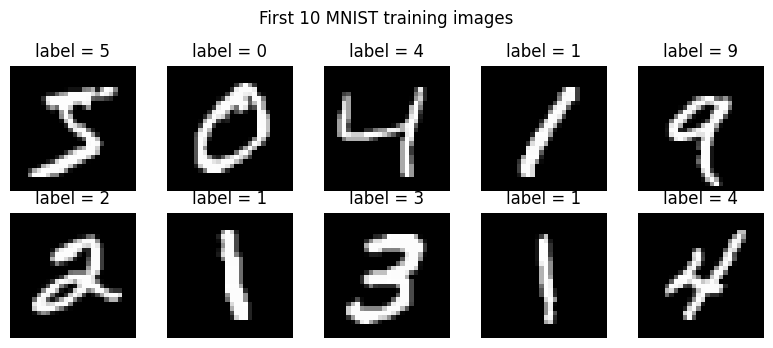

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for ax, img, label in zip(axes.flat, X_train_np[:10], y_train_np[:10]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"label = {label}")
    ax.axis("off")
plt.suptitle("First 10 MNIST training images")
plt.tight_layout()
plt.show()

## 4. From images to tensors

An MLP eats **flat vectors**, not 2D images:

1. **Flatten** each `28×28` image into a `784`-vector.
2. **Scale** pixels from `[0, 255]` to `[0, 1]` so gradients are well-behaved.

Labels become `int64` tensors (what `CrossEntropyLoss` expects).

In [4]:
X_train = torch.from_numpy(X_train_np).float().reshape(-1, 784) / 255.0
y_train = torch.from_numpy(y_train_np).long()
X_test  = torch.from_numpy(X_test_np).float().reshape(-1, 784) / 255.0
y_test  = torch.from_numpy(y_test_np).long()

print("X_train:", X_train.shape, "in [", X_train.min().item(), ",", X_train.max().item(), "]")
print("y_train:", y_train.shape)

X_train: torch.Size([60000, 784]) in [ 0.0 , 1.0 ]
y_train: torch.Size([60000])


## 5. A super-simple MLP

One hidden layer with ReLU, then a 10-way output (one logit per digit class):

$$
\underbrace{\mathbf{x}}_{784} \;\xrightarrow{\,W_1\mathbf{x}+\mathbf{b}_1\,}\; \underbrace{\mathbf{h}}_{64}\;\xrightarrow{\,\text{ReLU}\,}\;\underbrace{\mathbf{h}'}_{64}\;\xrightarrow{\,W_2\mathbf{h}'+\mathbf{b}_2\,}\;\underbrace{\mathbf{z}}_{10}
$$

The 10 outputs $\mathbf{z}$ are called **logits**. The predicted digit is `argmax(z)`. We do **not** add a softmax here — `CrossEntropyLoss` applies it internally for numerical stability.

In [5]:
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc2(h)

model = TinyMLP()
print(model)

TinyMLP(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


## 6. Predict *before* training

Right now, the network's weights are **random**. So whatever digit it predicts is essentially a random guess from `0–9` — we expect to be right only ~10 % of the time. This is our baseline.

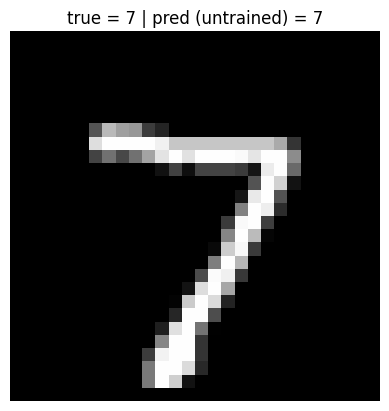

In [6]:
i = 0
with torch.no_grad():
    pred = model(X_test[i].unsqueeze(0)).argmax(dim=1).item()

plt.imshow(X_test_np[i], cmap="gray")
plt.title(f"true = {y_test[i].item()} | pred (untrained) = {pred}")
plt.axis("off")
plt.show()

## 7. The training recipe

Every training step performs the same four operations:

1. **Forward**: feed inputs through the model to get predictions (logits).
2. **Loss**: measure how wrong the predictions are with cross-entropy.
3. **Backward**: `loss.backward()` runs **backpropagation** — the chain rule applied through the computation graph — to compute $\partial L / \partial w$ and $\partial L / \partial b$ for every parameter.
4. **Step**: the optimizer nudges each parameter against its gradient, using a learning rate $\alpha$:

$$
w \;\leftarrow\; w \;-\; \alpha \,\frac{\partial L}{\partial w}, \qquad
b \;\leftarrow\; b \;-\; \alpha \,\frac{\partial L}{\partial b}
$$

We do this on **mini-batches** instead of the full 60,000 images at once — faster, less memory, and the small noise actually helps generalization.

In [7]:
alpha = 0.1
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=alpha)

EPOCHS = 3
BATCH = 128
N = X_train.shape[0]

for epoch in range(1, EPOCHS + 1):
    perm = torch.randperm(N)
    for start in range(0, N, BATCH):
        idx = perm[start : start + BATCH]
        xb, yb = X_train[idx], y_train[idx]

        loss = criterion(model(xb), yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"epoch {epoch}  last-batch loss = {loss.item():.4f}")

/home/erradi/.venvs/ml-env/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


epoch 1  last-batch loss = 0.3483
epoch 2  last-batch loss = 0.3029
epoch 3  last-batch loss = 0.2114


## 8. How well does it generalize?

Training loss can be misleading — a model can memorize. The honest score comes from the **test set**, which the model has never seen.

In [8]:
with torch.no_grad():
    test_acc = (model(X_test).argmax(dim=1) == y_test).float().mean().item()

print(f"test accuracy: {test_acc:.4f}")

test accuracy: 0.9375


## 9. Predict a test image *after* training

Same image as before — but now the network has learned. The bar chart on the right shows the network's confidence (softmax probabilities) over the 10 digit classes.

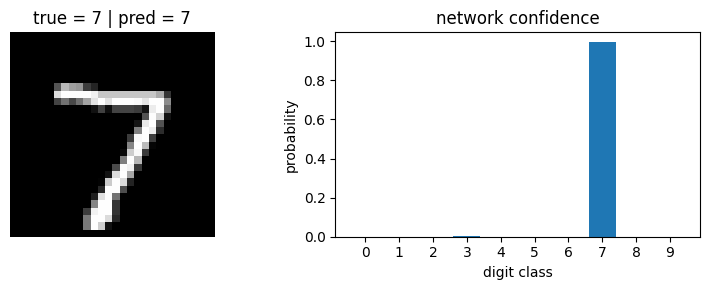

In [9]:
i = 0
with torch.no_grad():
    probs = torch.softmax(model(X_test[i].unsqueeze(0)), dim=1).squeeze().numpy()
pred = int(probs.argmax())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.imshow(X_test_np[i], cmap="gray")
ax1.set_title(f"true = {y_test[i].item()} | pred = {pred}")
ax1.axis("off")
ax2.bar(range(10), probs)
ax2.set_xticks(range(10))
ax2.set_xlabel("digit class")
ax2.set_ylabel("probability")
ax2.set_title("network confidence")
plt.tight_layout()
plt.show()

## Recap

In one short notebook we touched **every core idea** of training a neural network:

- A network is just stacked linear layers with non-linearities (ReLU).
- The output is **logits**; cross-entropy turns them into a learning signal.
- `loss.backward()` runs **backpropagation** to compute every gradient automatically.
- The optimizer applies $w \leftarrow w - \alpha \, \partial L / \partial w$ — repeat thousands of times.
- We measure honesty on a held-out **test set**.

Natural next steps: add more / wider hidden layers, swap SGD for Adam, or replace the MLP with a small CNN.